# Who Should Receive Which Promotion?

**🌐 Language:** **English** | [한국어 →](/who-should-be-treated-ko)

<small><em>Written by Haechang Cho · <a href="https://github.com/Funbucket">GitHub</a> · <a href="https://www.linkedin.com/in/hae-chang-cho/">LinkedIn</a></em></small>

Many problems in causal inference focus on the Average Treatment Effect (ATE). For example, the question "should we run a promotion or not?" compares a policy that offers the same promotion to all customers against one that offers it to no one.

But if the budget is limited and you need to maximize impact within it, the story changes. If promotion effects vary significantly across customers, a one-size-fits-all strategy may not be optimal.

- You waste marketing budget on always-converters who would have purchased regardless, and on lost causes who won't buy no matter what incentive they receive.
- sleeping dogs who react negatively to marketing actually cause losses, and
- you miss potential revenue by failing to prioritize high-responders.

The core question is therefore:

_"Which customers, when targeted, yield the greatest net profit?"_

Policy learning explores possible treatment rules and learns to maximize the overall average net profit. In other words, it answers the question: "Who should be treated?"

<img src="./assets/AJStyles&Undertaker.jpg" width="500"/>

In [1]:
import os
import tempfile
import warnings
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "matplotlib"))
os.environ.setdefault("MPLBACKEND", "Agg")
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "8")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split

from econml.dr import DRLearner
from econml.policy import DRPolicyForest, DRPolicyTree

warnings.filterwarnings('ignore')

SEED = 1
rng = np.random.default_rng(SEED)
np.random.seed(SEED)
sns.set_theme(style='whitegrid')

## Problem Setup

A software sales company wants to know whether incentives such as discounts or technical support actually increase software purchases, and which customers respond most effectively.

Ideally, one would run a randomized controlled trial (RCT) assigning different incentives randomly to each customer. In practice, however, factors such as cost, sales strategy, and the risk of losing major clients make randomized experiments difficult. This data is therefore observational, not from a randomized experiment.

The dataset contains information on approximately 2,000 customers, described by the following variables.

- Customer characteristics: detailed information on each customer's industry, size, revenue, and technology profile.
- Intervention: information on the incentive provided to each customer.
- Outcome: software purchase revenue over the year following the incentive.

| Variable        | Type | Description                                                                  |
| --------------- | ---- | ---------------------------------------------------------------------------- |
| Global Flag     | X    | Whether the customer has a global office (overseas branch)                   |
| Major Flag      | X    | Whether the customer is a large consumer in its industry (vs. SMC or SMB)    |
| SMC Flag        | X    | Whether the customer is a small-medium corporation (vs. Major or SMB)        |
| Commercial Flag | X    | Whether the customer's business type is commercial (vs. public sector)       |
| IT Spend        | X    | Amount spent on IT-related purchases                                         |
| Employee Count  | X    | Number of employees                                                          |
| PC Count        | X    | Number of PCs used by the customer                                           |
| Size            | X    | Customer size measured by annual total revenue                               |
| Tech Support    | T    | Whether the customer received technical support (binary)                     |
| Discount        | T    | Whether the customer received a discount (binary)                            |
| Revenue         | Y    | Customer revenue from software purchases                                     |


Since both `Tech Support` and `Discount` are interventions, we combine them to define four treatments:

$$
A_i \in \{0, 1, 2, 3\}
$$

Each treatment means:
- $A_i = 0$: no intervention
- $A_i = 1$: technical support only
- $A_i = 2$: discount only
- $A_i = 3$: both technical support and discount

In [2]:
data = pd.read_csv('./data/multi_attribution_sample.csv')
data.columns = data.columns.str.strip()

covariates = [
    'Global Flag',
    'Major Flag',
    'SMC Flag',
    'Commercial Flag',
    'IT Spend',
    'Employee Count',
    'PC Count',
    'Size',
]
outcome = 'Revenue'

TREATMENT_NAMES = {
    0: 'none',
    1: 'tech_support_only',
    2: 'discount_only',
    3: 'discount_plus_support',
}
TREATMENT_LABELS = [TREATMENT_NAMES[i] for i in range(4)]

required_columns = covariates + ['Tech Support', 'Discount', outcome]
for col in required_columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')

policy_df = data[required_columns].dropna().copy()
policy_df['treatment'] = (
    2 * policy_df['Discount'].astype(int)
    + policy_df['Tech Support'].astype(int)
).astype(int)
policy_df['treatment_name'] = policy_df['treatment'].map(TREATMENT_NAMES)

n = len(policy_df)
X = policy_df[covariates].to_numpy()
Y = policy_df[outcome].to_numpy(dtype=float)
A = policy_df['treatment'].to_numpy(dtype=int)

print(policy_df.shape)
policy_df.head()


(2000, 13)


,Global Flag,Major Flag,SMC Flag,Commercial Flag,IT Spend,Employee Count,PC Count,Size,Tech Support,Discount,Revenue,treatment,treatment_name
0,1,0,1,0,45537,26,26,152205,0,1,17688.36300,2,discount_only
1,0,0,1,1,20842,107,70,159038,0,1,14981.43559,2,discount_only
2,0,0,0,1,82171,10,7,264935,1,1,32917.13894,3,discount_plus_support
3,0,0,0,0,30288,40,39,77522,1,1,14773.76855,3,discount_plus_support
4,0,0,1,0,25930,37,43,91446,1,1,17098.69823,3,discount_plus_support


### Cost Setup

In real-world operations, costs must be considered alongside incentive effects. Furthermore, the cost of the same incentive can vary across customers depending on their characteristics.

For example, technical support may require more support hours for larger companies, while discounts may need to be deeper for larger customers.

Since this dataset does not include actual cost information, we simulate costs that vary with customer characteristics.

Technical support cost increases with employee count, and discount cost increases with customer size.

We use the log-normal distribution so that costs are always positive and can exhibit the heavy-tailed behavior seen in practice.

$$
C_i(\text{tech}) \sim \text{LogNormal}(\log C_{\text{tech}} + 0.5 \cdot \tilde{e}_i,\ 0.3)
$$

$$
C_i(\text{disc}) \sim \text{LogNormal}(\log C_{\text{disc}} + 0.4 \cdot \tilde{s}_i,\ 0.3)
$$

where $\tilde{e}_i$ is the standardized employee count and $\tilde{s}_i$ is the standardized company size.

With per-customer costs defined this way, the net outcome is:

$$
Y_i^{net} = Y_i - C_i(A_i)
$$

Using $Y_i^{net}$ as the outcome when computing AIPW scores means $\hat\Gamma_{i,a}$ naturally estimates $E[Y(a) - C(a) \mid X_i]$. Policy learning and evaluation based on AIPW thus automatically incorporate costs.

In [3]:
COST_TECH_SUPPORT = 4_000.0   # baseline cost for tech support
COST_DISCOUNT     = 5_000.0   # baseline  cost for discount


rng_c = np.random.default_rng(SEED + 99)
emp_idx  = covariates.index('Employee Count')
size_idx = covariates.index('Size')

emp_z  = (X[:, emp_idx]  - X[:, emp_idx].mean())  / (X[:, emp_idx].std()  + 1e-8)
size_z = (X[:, size_idx] - X[:, size_idx].mean()) / (X[:, size_idx].std() + 1e-8)

c_tech = rng_c.lognormal(mean=np.log(COST_TECH_SUPPORT) + 0.5 * emp_z, sigma=0.3)
c_disc = rng_c.lognormal(mean=np.log(COST_DISCOUNT) + 0.4 * size_z, sigma=0.3)

c_tech = np.clip(c_tech, 200.0, 40_000.0)
c_disc = np.clip(c_disc, 200.0, 30_000.0)

C_obs = np.select(
    [A == 1, A == 2, A == 3],
    [c_tech, c_disc, c_tech + c_disc],
    default=0.0,
)

Y_net = Y - C_obs

pd.DataFrame({
    'treatment': TREATMENT_LABELS,
    'mean_cost':  [C_obs[A == a].mean() if (A == a).sum() > 0 else 0.0 for a in range(4)],
    'std_cost':   [C_obs[A == a].std()  if (A == a).sum() > 0 else 0.0 for a in range(4)],
    'mean_revenue':     [Y[A == a].mean()     for a in range(4)],
    'mean_net_revenue': [Y_net[A == a].mean() for a in range(4)],
})

,treatment,mean_cost,std_cost,mean_revenue,mean_net_revenue
0,none,0.000000,0.000000,6585.891792,6585.891792
1,tech_support_only,5037.815894,4917.641358,15104.111534,10066.295640
2,discount_only,5181.570334,3043.343172,12247.935953,7066.365619
3,discount_plus_support,12665.283296,7375.490125,26784.124649,14118.841353


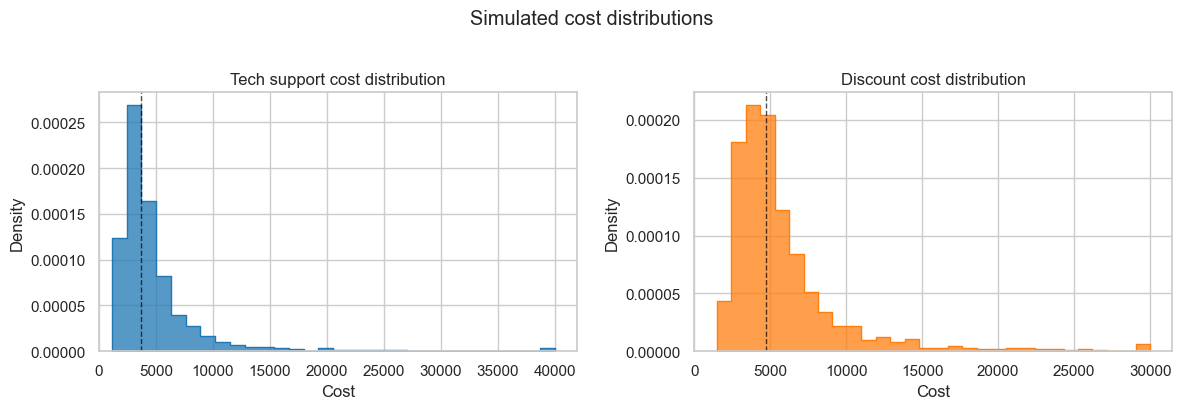

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(c_tech, bins=30, stat='density', element='step', fill=True, ax=axes[0], color='tab:blue')
axes[0].axvline(np.median(c_tech), color='black', ls='--', lw=1, alpha=0.7)
axes[0].set_title('Tech support cost distribution')
axes[0].set_xlabel('Cost')
axes[0].set_ylabel('Density')
axes[0].set_xlim(left=0)

sns.histplot(c_disc, bins=30, stat='density', element='step', fill=True, ax=axes[1], color='tab:orange')
axes[1].axvline(np.median(c_disc), color='black', ls='--', lw=1, alpha=0.7)
axes[1].set_title('Discount cost distribution')
axes[1].set_xlabel('Cost')
axes[1].set_ylabel('Density')
axes[1].set_xlim(left=0)

plt.suptitle('Simulated cost distributions', y=1.02)
plt.tight_layout()
plt.show()

### Data Split

Using the same data for policy learning and evaluation leads to overestimation. To prevent this, we split the data into train and test sets. Policies are learned on the train set and evaluated using AIPW scores computed on the test set.

The same split is used for propensity estimation in the positivity check.

In [5]:
idx = np.arange(len(policy_df))
train_idx, test_idx = train_test_split(
    idx,
    test_size=0.5,
    stratify=A,
    random_state=SEED,
)

X_train = X[train_idx]
X_test = X[test_idx]
A_train = A[train_idx]
A_test = A[test_idx]
Y_net_train = Y_net[train_idx]
Y_net_test = Y_net[test_idx]

print(f"Train: {len(train_idx)} \nTest: {len(test_idx)}")

Train: 1000 
Test: 1000


### Exploratory Data Analysis and Diagnostics

Before entering policy learning, we first examine the data structure across the four treatments ($A \in \{0,1,2,3\}$).

1. Sample size per treatment: are there enough observations in each treatment?
2. Mean customer characteristics per treatment: which customer segments tend to receive which treatment?
3. Revenue distribution per treatment: how do Revenue scale, variance, and outlier patterns differ across treatments?
4. Positivity check: are all treatments sufficiently co-observed across the range of customer characteristics?

In [6]:
treatment_counts = policy_df['treatment_name'].value_counts().reindex(TREATMENT_LABELS).rename_axis('treatment').to_frame('count')
treatment_counts['share'] = treatment_counts['count'] / len(policy_df)

display(treatment_counts)

,count,share
treatment,,
none,517,0.2585
tech_support_only,462,0.2310
discount_only,477,0.2385
discount_plus_support,544,0.2720


The actual sample sizes are `none` 517, `tech_support_only` 462, `discount_only` 477, and `discount_plus_support` 544. Each treatment's share ranges from 23.1% to 27.2%, indicating a reasonably balanced distribution with no treatment severely underrepresented.

The sample distribution is therefore stable for policy learning with four treatments.

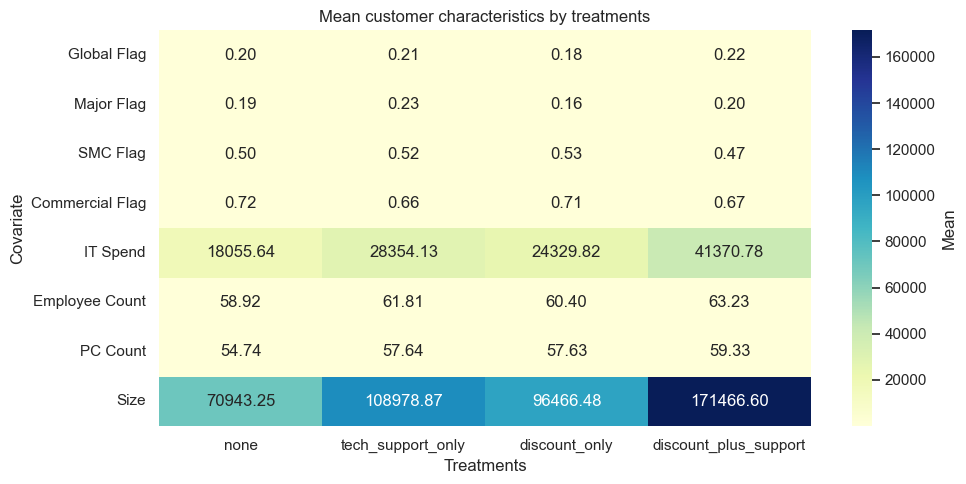

In [7]:
treatment_covariate_means = (
    policy_df
    .groupby('treatment_name')[covariates]
    .mean()
    .reindex(TREATMENT_LABELS)
)

plt.figure(figsize=(10, 5))
sns.heatmap(treatment_covariate_means.T, annot=True, fmt='.2f', cmap='YlGnBu', cbar_kws={'label': 'Mean'})
plt.xlabel('Treatments')
plt.ylabel('Covariate')
plt.title('Mean customer characteristics by treatments')
plt.tight_layout()

Customer characteristics are not identical across treatments. The mean `Size` and `IT Spend` differ by treatment group, and the `discount_plus_support` group includes more large customers. From a domain perspective, the type of support needed may also differ with customer scale and IT spend.

These differences suggest that treatment effects may vary with customer characteristics. Policy learning and evaluation therefore use AIPW so these differences are accounted for.

,treatment,treatment_name,count,mean,median,std,min,max
0,0,none,517,6585.891792,6123.187067,3363.163462,-616.572451,21445.05937
1,1,tech_support_only,462,15104.111534,14483.719320,5400.319858,4619.491361,40166.67407
2,2,discount_only,477,12247.935953,10454.932500,7472.178476,889.975653,41818.39213
3,3,discount_plus_support,544,26784.124649,23560.252890,13124.968083,5903.906880,86006.92445


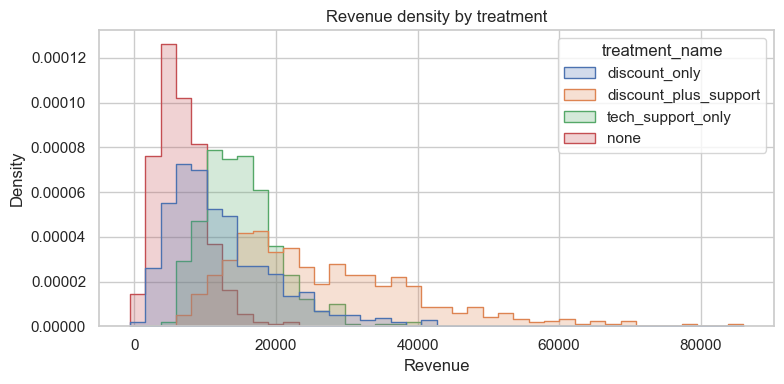

In [8]:
treatment_revenue = (
    policy_df
    .groupby(['treatment', 'treatment_name'])[outcome]
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    .reset_index()
)
display(treatment_revenue)

plt.figure(figsize=(8, 4))

sns.histplot(
    data=policy_df,
    x=outcome,
    hue='treatment_name',
    bins=40,
    element='step',
    stat='density',
    common_norm=False
)

plt.title('Revenue density by treatment')
plt.tight_layout()
plt.show()

Mean Revenue is approximately 6,586 for `none`, 12,248 for `discount_only`, 15,104 for `tech_support_only`, and 26,784 for `discount_plus_support`.

As noted above, larger customers tend to receive stronger interventions, so the raw mean differences confound customer characteristics with actual treatment effects. Evaluating policy based on unadjusted means would therefore be misleading.

We should instead rely on AIPW-based policy evaluation for proper comparison.

### Identification Assumptions

For AIPW estimation from observational data to be causally valid, two assumptions are required.

1. Unconfoundedness

    $$\{Y_i(0), Y_i(1), Y_i(2), Y_i(3)\} \perp A_i \mid X_i$$

    Conditional on observed covariates $X_i$, treatment assignment must be independent of potential outcomes. That is, we assume variables such as customer size, IT spend, and employee count sufficiently explain treatment assignment.

2. Positivity

    $$P(A_i = a \mid X_i = x) > 0 \quad \forall a \in \{0,1,2,3\},\ \forall x$$

    Each treatment must be observed with positive probability across all ranges of customer characteristics.

Positivity is verified directly by estimating propensity scores:

$$
e_a(x) = P(A_i = a \mid X_i=x)
$$

We also check whether propensity scores are severely skewed. If $\hat{e}_a(x)$ is very close to zero for some customers under some treatment, those observations receive excessively large weights, which can destabilize estimation.

In [9]:
multi_propensity = RandomForestClassifier(
    n_estimators=400,
    min_samples_leaf=20,
    random_state=SEED,
    n_jobs=1,
)
multi_propensity.fit(X_train, A_train)
e_hat_raw = multi_propensity.predict_proba(X_test)

propensity_summary = pd.DataFrame({
    'treatment': TREATMENT_LABELS,
    'mean_propensity': e_hat_raw.mean(axis=0),
    'min_propensity': e_hat_raw.min(axis=0),
    'p01_propensity': np.quantile(e_hat_raw, 0.01, axis=0),
    'propensity_below_0_05_rate': (e_hat_raw < 0.05).mean(axis=0),
})
display(propensity_summary)

,treatment,mean_propensity,min_propensity,p01_propensity,propensity_below_0_05_rate
0,none,0.263941,0.057600,0.066831,0.0
1,tech_support_only,0.229863,0.126582,0.156283,0.0
2,discount_only,0.237934,0.125638,0.141322,0.0
3,discount_plus_support,0.268263,0.087299,0.101304,0.0


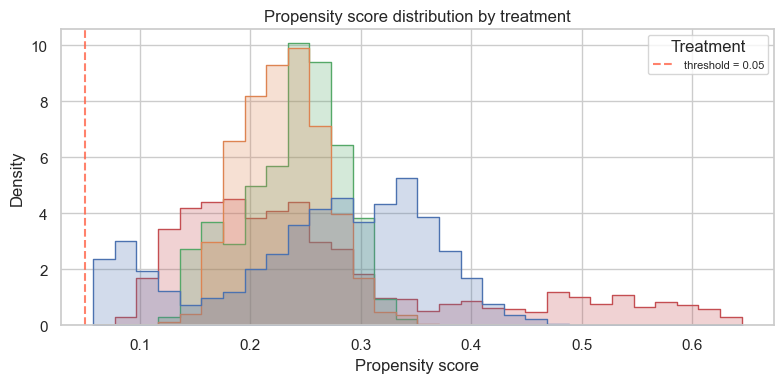

In [10]:
prop_df = pd.DataFrame(e_hat_raw, columns=TREATMENT_LABELS)
prop_long = prop_df.melt(var_name='treatment', value_name='propensity')

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(
    data=prop_long, x='propensity', hue='treatment',
    bins=30, element='step', stat='density', common_norm=False, ax=ax,
)

ax.axvline(0.05, color='tomato', lw=1.5, ls='--', alpha=0.8, label='threshold = 0.05')
ax.legend(title='Treatment', fontsize=8)
ax.set_xlabel('Propensity score')
ax.set_ylabel('Density')
ax.set_title('Propensity score distribution by treatment')
plt.tight_layout()
plt.show()

In this dataset the minimum value of $\hat e_a(X_i)$ is approximately 0.058, and no observations have `e_hat < 0.05`. Excessively large weights from extremely small propensity scores are therefore not a major concern here.

The propensity distributions for all four treatments overlap well in the graph, and no clear positivity violations are observed.

## Policy Learning Methods

We compare three policy learning approaches.

- Plug-in Policy (DRLearner)

    First estimates per-customer CATE, then selects the treatment with the highest expected net benefit.

    This is a flexible approach with no constraints on policy form, but final performance depends heavily on the quality of CATE estimation.

- DRPolicyTree

    DRPolicyTree learns a policy by directly maximizing the AIPW score.

    The policy structure is constrained to a shallow decision tree, making results interpretable as decision rules. This is useful when policy interpretability and explainability matter.

- DRPolicyForest

    DRPolicyForest also directly maximizes the AIPW score but uses a forest rather than a single tree.

    A single tree has a simple structure but can exhibit high variance. A forest averages across many trees, reducing variance and learning heterogeneous treatment effects more stably.

    However, the resulting policy is harder to interpret as a single clear decision rule set.

All three policies are learned on the train set and compared using the same test set. It is important to use separate data for learning and evaluation, as using the training data for evaluation leads to overestimation.

### Plug-in Policy

A plug-in policy first estimates per-customer treatment effects (CATE) and then uses those estimates to construct the policy.

For binary treatment, the standard rule is to treat if $\hat\tau(x) > 0$, or if costs are present, treat when $\hat\tau(x) > c(x)$.

With multiple treatments, we compare relative effects against a baseline. Here we set `none` (no treatment) as the baseline and use `DRLearner` to estimate:

$$
\hat\tau_a(x) = \widehat{\mathbb{E}}[Y^{net}(a) - Y^{net}(0) \mid X=x]
\qquad a \in \{1,2,3\}
$$

Since the relative effect of the baseline treatment is 0, we compare the following four values per customer:

$$
[0, \hat\tau_1(x), \hat\tau_2(x), \hat\tau_3(x)]
$$

and select the treatment with the highest value:

$$
\hat\pi_{plugin}(x) = \arg\max_{a \in \{0,1,2,3\}} \widehat{\mathbb{E}}[Y^{net}(a) - Y^{net}(0) \mid X=x]
$$

This approach is intuitive and flexible, but it depends heavily on the quality of CATE estimation. The learned policy is therefore evaluated on a separate test set using AIPW value.

> **Note** One might ask "why not just select the treatment with the highest $\hat\Gamma_{i,a}$ for each customer?" However, AIPW scores have very high variance at the individual observation level, so a policy built by pointwise argmax overfits to noise. AIPW scores must always be used in aggregated form — for example, summed across observations for policy evaluation (value estimation, cost curves, etc.), averaged within nodes for DRPolicyTree/Forest, or used as pseudo-outcomes for regression in DRLearner.

In [11]:
dr_cate = DRLearner(
    model_regression=RandomForestRegressor(
        n_estimators=400,
        min_samples_leaf=20,
        random_state=SEED,
        n_jobs=1,
    ),
    model_propensity=RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=20,
        random_state=SEED,
        n_jobs=1,
    ),
    model_final=RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=20,
        random_state=SEED,
        n_jobs=1,
    ),
    categories=[0, 1, 2, 3],
    min_propensity=0.02,
    cv=3,
    random_state=SEED,
)
dr_cate.fit(Y_net_train, A_train, X=X_train)

# returns E[Y_net(a) - Y_net(0) | X] for each treatment relative to none (baseline)
cate_vs_none = dr_cate.const_marginal_effect(X_test)
plugin_treatment_values = np.column_stack([
    np.zeros(len(X_test)),  # none: baseline, relative effect = 0
    cate_vs_none,
])
pi_plugin = np.argmax(plugin_treatment_values, axis=1)

In [12]:
pd.Series(pi_plugin).map(TREATMENT_NAMES).value_counts(normalize=True).reindex(TREATMENT_LABELS).fillna(0)

none                     0.092
tech_support_only        0.499
discount_only            0.035
discount_plus_support    0.374
Name: proportion, dtype: float64

In [13]:
none_idx = np.where(pi_plugin == 0)[0][:3]
tech_idx = np.where(pi_plugin == 1)[0][:3]
both_idx = np.where(pi_plugin == 3)[0][:3]
sample_ids = np.concatenate([none_idx, tech_idx, both_idx])

df_plugin_sample = pd.DataFrame(X_test[sample_ids], columns=covariates)[['Size', 'Employee Count', 'IT Spend']]
df_plugin_sample['assigned_treatment'] = pd.Series(pi_plugin[sample_ids]).map(TREATMENT_NAMES).values
df_plugin_sample[['τ_tech', 'τ_disc', 'τ_both']] = np.round(cate_vs_none[sample_ids], 0).astype(int)
df_plugin_sample.index = pd.RangeIndex(len(df_plugin_sample))
df_plugin_sample

,Size,Employee Count,IT Spend,assigned_treatment,τ_tech,τ_disc,τ_both
0,96204,142,17655,none,-6140,-1419,-1715
1,25390,178,7971,none,-14556,-4252,-7277
2,66555,279,19899,none,-17629,-2896,-16555
3,70868,20,26263,tech_support_only,4265,-41,4146
4,24152,18,4610,tech_support_only,4174,-2315,-772
5,54855,63,14772,tech_support_only,2061,-698,587
6,399228,36,133052,discount_plus_support,7849,-1278,11819
7,181704,24,59529,discount_plus_support,9171,5221,10249
8,294377,37,112485,discount_plus_support,7124,877,9048


The plug-in policy assigns `tech_support_only` to approximately 50% of customers, `discount_plus_support` to 37%, and `none` to about 9%.

After accounting for costs, some customers are expected to have negative net profit from treatment, so the policy chooses not to treat them.

### Policy Tree

In practice, policy interpretability is often as important as performance. Shallow decision tree-based policies are frequently used in operations for the following reasons:

- **Stakeholder communication**: the intuitive decision rule branching structure makes policies easy to explain and share.
- **Fairness review**: the explicit structure of who receives which treatment makes it easy to audit for bias.
- **Operational stability**: simple rule-based policies are more manageable in production than complex models.

Rather than searching for the optimal policy across all possible functions, we restrict the search to a limited policy class $\Pi$:

$$
\hat\pi = \arg\max_{\pi \in \Pi}
\frac{1}{n}\sum_{i=1}^{n} \widehat\Gamma_{i,\pi(X_i)}
$$

Policy Tree restricts $\Pi$ to shallow decision trees. With a small depth, the resulting policy is human-readable. We use `DRPolicyTree` from `econml`.

To prevent unstable value estimation in small leaves under multi-treatment settings, `min_samples_leaf` is used to ensure leaves are large enough.

In [14]:
dr_policy_tree = DRPolicyTree(
    max_depth=2,
    min_samples_leaf=30,
    model_regression=RandomForestRegressor(
        n_estimators=400,
        min_samples_leaf=20,
        random_state=SEED,
        n_jobs=1,
    ),
    model_propensity=RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=20,
        random_state=SEED,
        n_jobs=1,
    ),
    categories=[0, 1, 2, 3],
    min_propensity=0.02,
    cv=3,
    random_state=SEED,
)
dr_policy_tree.fit(Y_net_train, A_train, X=X_train)
pi_tree = dr_policy_tree.predict(X_test).astype(int).ravel()

pd.Series(pi_tree).map(TREATMENT_NAMES).value_counts(normalize=True).reindex(TREATMENT_LABELS).fillna(0)


none                     0.199
tech_support_only        0.475
discount_only            0.000
discount_plus_support    0.326
Name: proportion, dtype: float64

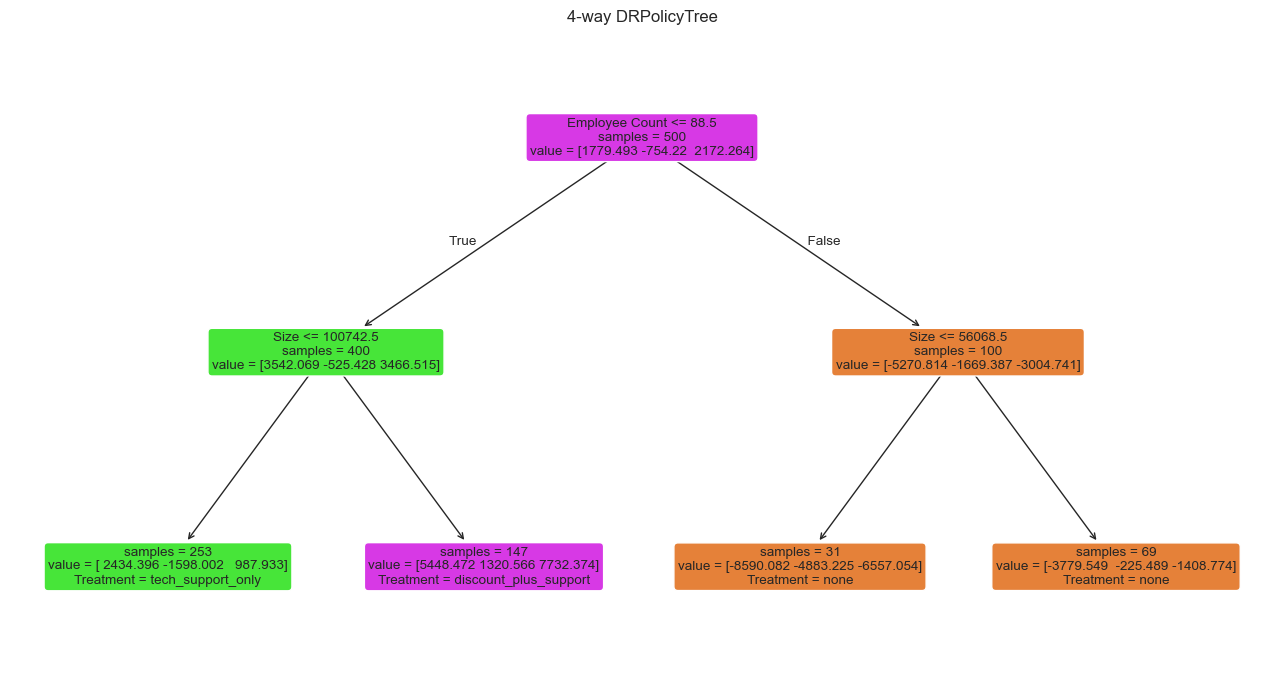

In [15]:
fig, ax = plt.subplots(figsize=(13, 7))
dr_policy_tree.plot(feature_names=covariates, treatment_names=TREATMENT_LABELS, ax=ax)
ax.set_title('4-way DRPolicyTree')
plt.tight_layout()

This tree policy primarily splits customers by `Size`. Notably, it assigns `none` to approximately 20% of customers — after accounting for costs, the expected net profit from treatment is low enough for some customers that not treating them is the better choice.

Overall, the policy assigns `discount_plus_support` to large customers and `tech_support_only` to the rest, while choosing `none` for customers with low expected net profit.

### Policy Forest

Policy Forest learns policies more stably by aggregating many trees.

Like DRPolicyTree, DRPolicyForest directly maximizes the AIPW score, but it averages across many trees instead of using a single one. This reduces variance and allows more stable learning of complex heterogeneous treatment effects.

We use `DRPolicyForest` from `econml`.

Unlike tree-based policies, the resulting policy cannot be easily expressed as a single clear decision rule. After fitting, we compare policy values using AIPW scores from the same test set.

In [16]:
dr_policy_forest = DRPolicyForest(
    n_estimators=400,
    max_depth=5,
    min_samples_leaf=30,
    model_regression=RandomForestRegressor(
        n_estimators=400,
        min_samples_leaf=20,
        random_state=SEED,
        n_jobs=1,
    ),
    model_propensity=RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=20,
        random_state=SEED,
        n_jobs=1,
    ),
    categories=[0, 1, 2, 3],
    min_propensity=0.02,
    cv=3,
    random_state=SEED,
    n_jobs=1,
)
dr_policy_forest.fit(Y_net_train, A_train, X=X_train)
pi_forest = dr_policy_forest.predict(X_test).astype(int).ravel()

pd.Series(pi_forest).map(TREATMENT_NAMES).value_counts(normalize=True).reindex(TREATMENT_LABELS).fillna(0)


none                     0.114
tech_support_only        0.469
discount_only            0.000
discount_plus_support    0.417
Name: proportion, dtype: float64

DRPolicyForest shows a treatment assignment pattern broadly similar to the plug-in policy. It assigns `none` to 11%, `tech_support_only` to 47%, and `discount_plus_support` to 42% — a slightly higher share of `discount_plus_support` compared to the plug-in policy.

### Feature Importance

DRPolicyForest has no single tree structure, so the policy cannot be directly interpreted as a set of branching rules. However, `feature_importances_` provides a way to understand which customer characteristics most influence treatment assignment decisions.

`feature_importances_` is a normalized score measuring how much each feature induces policy heterogeneity — that is, how much it drives different treatment assignments across customers — during the forest's splitting process. A higher score means the feature plays a larger role in determining the optimal treatment for each customer.

Note that these scores are best used as an exploratory signal indicating "which features were frequently used as splitting criteria," rather than as a definitive causal interpretation.

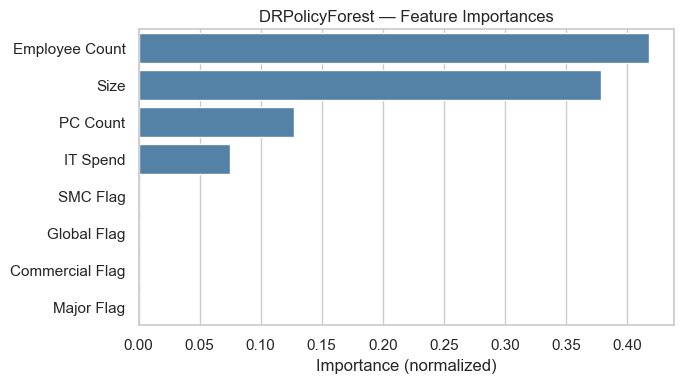

,feature,importance
0,Employee Count,0.417657
1,Size,0.378824
2,PC Count,0.127452
3,IT Spend,0.075229
4,SMC Flag,0.000479
5,Global Flag,0.000194
6,Commercial Flag,0.000147
7,Major Flag,0.000017


In [17]:
importances = dr_policy_forest.feature_importances_
fi_df = pd.DataFrame({
    'feature': covariates,
    'importance': importances,
}).sort_values('importance', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=fi_df, x='importance', y='feature', ax=ax, color='steelblue')
ax.set_title('DRPolicyForest — Feature Importances')
ax.set_xlabel('Importance (normalized)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

display(fi_df)

`Employee Count` (42%) and `Size` (38%) together account for approximately 80% of total importance, confirming that customer scale and workforce size are the primary drivers of treatment assignment. `PC Count` (13%) and `IT Spend` (8%) contribute modestly, while the remaining flag variables have a negligible impact.

This is consistent with DRPolicyTree's primary split on `Size`. Both models agree that customer scale is the strongest signal for determining the optimal treatment — whether to offer technical support, a discount, or nothing.

## Policy Evaluation

We now compare the learned policies using AIPW scores from the same test set.

As benchmarks, we also include constant policies that apply the same treatment to every customer:

- `all_none`
- `all_tech_support_only`
- `all_discount_only`
- `all_discount_plus_support`

For example, `all_discount_plus_support` represents the average net profit when both technical support and a discount are provided to every customer.

By contrast, the learned policies assign different treatments depending on each customer's characteristics $X_i$.

If a learned policy's value exceeds the best constant policy, it means that customer-level targeting is more effective than applying the same treatment to everyone.

The AIPW (Augmented Inverse Probability Weighting) score is defined as:

$$
\hat\Gamma_{i,a} = \hat\mu_a(X_i) + \frac{\mathbf{1}[A_i=a]}{\hat e_a(X_i)}\bigl(Y_i^{net} - \hat\mu_a(X_i)\bigr)
$$

- $\hat\mu_a(X_i)$: predicted $E[Y^{net}(a)\mid X_i]$ from the outcome model
- $\hat e_a(X_i)$: predicted $P(A_i=a\mid X_i)$ from the propensity model
- The second term corrects the difference between observed and predicted values via IPW.

This structure ensures unbiasedness holds as long as either the outcome model or the propensity model is correctly specified. This property is called doubly robust.

- If the outcome model is correct: the expected value of the IPW correction term approaches zero, so $\hat\mu_a(X_i)$ contributes directly.
- If the propensity model is correct: the IPW correction term removes the bias of the outcome model.

This score is used to estimate the value of each learned policy.

In [18]:
e_hat_net = np.clip(e_hat_raw, 0.02, 0.98)
e_hat_net = e_hat_net / e_hat_net.sum(axis=1, keepdims=True)

gamma_net = np.zeros((len(X_test), 4))
mu_hat_net = np.zeros((len(X_test), 4))

for treatment_id in range(4):
    outcome_model = RandomForestRegressor(
        n_estimators=400,
        min_samples_leaf=20,
        random_state=SEED,
        n_jobs=1,
    )
    outcome_model.fit(X_train[A_train == treatment_id], Y_net_train[A_train == treatment_id])
    mu_a = outcome_model.predict(X_test)
    observed_a = (A_test == treatment_id).astype(float)

    gamma_net[:, treatment_id] = mu_a + observed_a / e_hat_net[:, treatment_id] * (Y_net_test - mu_a)
    mu_hat_net[:, treatment_id] = mu_a

In [19]:
sample_ids = np.arange(5)

sample_prediction_table = pd.concat(
    {
        'sample': pd.DataFrame({
            'sample_id': sample_ids,
            'actual_arm': pd.Series(A_test[sample_ids]).map(TREATMENT_NAMES).to_numpy(),
            'observed_net_outcome': Y_net_test[sample_ids],
        }),
        'e_hat': pd.DataFrame(e_hat_net[sample_ids], columns=TREATMENT_LABELS),
        'mu_hat': pd.DataFrame(mu_hat_net[sample_ids], columns=TREATMENT_LABELS),
        'gamma': pd.DataFrame(gamma_net[sample_ids], columns=TREATMENT_LABELS),
    },
    axis=1,
)

sample_prediction_table

sample                                                 e_hat  \
  sample_id             actual_arm observed_net_outcome      none   
0         0  discount_plus_support          9254.558541  0.248633   
1         1      tech_support_only          7702.861662  0.211087   
2         2      tech_support_only          5062.184420  0.376570   
3         3                   none          8930.495022  0.339653   
4         4                   none          8156.575502  0.312265   

                                                               mu_hat  \
  tech_support_only discount_only discount_plus_support          none   
0          0.267338      0.272366              0.211662   5370.099281   
1          0.307204      0.243394              0.238315  10468.942522   
2          0.241901      0.256261              0.125268   2879.741786   
3          0.194701      0.246505              0.219142   8458.779217   
4          0.250021      0.312123              0.125590  10137.469821   

                                                                gamma  \
  tech_support_only discount_only discount_plus_support          none   
0       9559.777763   4547.484552           6984.731609   5370.099281   
1       6728.988419   8373.316633          11121.826609  10468.942522   
2       5449.409859    937.515103           2959.514347   2879.741786   
3       8254.372069   6054.598973           6560.028069   9847.598052   
4       3378.748035   5743.802939           2988.217314   3793.845054   

                                                         
  tech_support_only discount_only discount_plus_support  
0       9559.777763   4547.484552          17708.540116  
1       9899.108508   8373.316633          11121.826609  
2       3848.652052    937.515103           2959.514347  
3       8254.372069   6054.598973           6560.028069  
4       3378.748035   5743.802939           2988.217314

In [20]:
policy_assignments = {
    **{f'all_{treatment_name}': np.full(len(X_test), treatment_id) for treatment_id, treatment_name in TREATMENT_NAMES.items()},
    'plugin_drlearner_4treatment': pi_plugin,
    'dr_policy_tree_4treatment': pi_tree,
    'dr_policy_forest_4treatment': pi_forest,
}

eval_rows = []
for policy_name, policy_assignment in policy_assignments.items():
    pi = np.asarray(policy_assignment).astype(int).ravel()
    scores = gamma_net[np.arange(len(pi)), pi]

    row = {
        'policy': policy_name,
        'value': scores.mean(),
        'value_se': scores.std(ddof=1) / np.sqrt(len(scores)),
    }
    for treatment_id, treatment_name in TREATMENT_NAMES.items():
        row[f'rate_{treatment_name}'] = np.mean(pi == treatment_id)
    eval_rows.append(row)

policy_eval = pd.DataFrame(eval_rows)
policy_eval['ci_lower'] = policy_eval['value'] - 1.96 * policy_eval['value_se']
policy_eval['ci_upper'] = policy_eval['value'] + 1.96 * policy_eval['value_se']

display_cols = ['policy', 'value', 'ci_lower', 'ci_upper'] + [f'rate_{n}' for n in TREATMENT_LABELS]
policy_eval.sort_values('value', ascending=False)[display_cols]

,policy,value,ci_lower,ci_upper,rate_none,rate_tech_support_only,rate_discount_only,rate_discount_plus_support
4,plugin_drlearner_4treatment,11797.813147,11270.046369,12325.579926,0.092,0.499,0.035,0.374
6,dr_policy_forest_4treatment,11619.027195,11094.858344,12143.196046,0.114,0.469,0.000,0.417
5,dr_policy_tree_4treatment,11148.549665,10700.702938,11596.396392,0.199,0.475,0.000,0.326
1,all_tech_support_only,10526.594766,9833.110122,11220.079410,0.000,1.000,0.000,0.000
3,all_discount_plus_support,10136.725288,9439.461674,10833.988903,0.000,0.000,0.000,1.000
2,all_discount_only,7545.092661,6993.547407,8096.637915,0.000,0.000,1.000,0.000
0,all_none,7249.345467,6955.447432,7543.243502,1.000,0.000,0.000,0.000


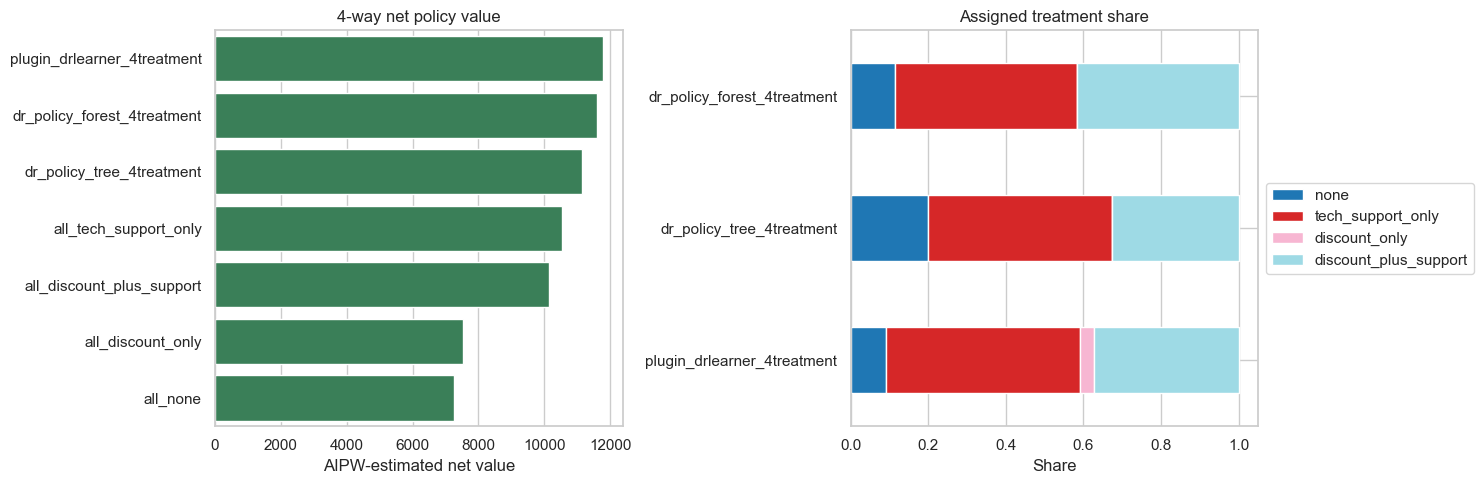

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_df = policy_eval.sort_values('value', ascending=False)
sns.barplot(data=plot_df, x='value', y='policy', ax=axes[0], color='seagreen')
axes[0].set_title('4-way net policy value')
axes[0].set_xlabel('AIPW-estimated net value')
axes[0].set_ylabel('')

treatment_rate_cols = [f'rate_{name}' for name in TREATMENT_LABELS]
rate_df = policy_eval.set_index('policy')[treatment_rate_cols]
rate_df.columns = TREATMENT_LABELS
rate_df.loc[['plugin_drlearner_4treatment', 'dr_policy_tree_4treatment', 'dr_policy_forest_4treatment']].plot(kind='barh', stacked=True, ax=axes[1], colormap='tab20')
axes[1].set_title('Assigned treatment share')
axes[1].set_xlabel('Share')
axes[1].set_ylabel('')
axes[1].legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()

All three learned policies achieve higher value than any constant policy, confirming that assigning different treatments by customer is more effective than treating everyone the same.

Among the learned policies, DRLearner plug-in (11,810) ranked first, followed by DRPolicyForest (11,626) and DRPolicyTree (11,148). However, since the plug-in and forest confidence intervals overlap substantially, the difference between them is not statistically clear. In theory, DR policies that directly optimize the AIPW score should have an advantage, but in practice the outcome depends on sample size and data characteristics. The tree policy trades some performance for an interpretable structure.

Among constant policies, `all_tech_support_only` (10,527) performed best. `all_discount_plus_support` (10,137) falls short because discount costs scale with customer size, so for some customers the discount benefit does not sufficiently offset the cost.

## Policy Comparison under Budget Constraints

So far we have compared policies by their overall AIPW value. In practice, however, budgets are limited. Cost curves are useful for comparing which policy is more efficient within the same budget.

### Estimating Per-Customer Expected Costs

To construct cost curves, we first estimate $E[C(a) \mid X_i]$ per customer. Since actual costs are observed only for the treatment the customer received, we fit a separate cost regression model on the training data for each treatment and apply it to the test set.

In [22]:
# Estimate E[C(a) | X] per treatment
# c_hat_test[i, a] = predicted cost for customer i under treatment a
c_true_by_treatment = {1: c_tech, 2: c_disc, 3: c_tech + c_disc}

c_hat_test = np.zeros((len(X_test), 4))   # treatment 0 → cost = 0
for treatment_id in [1, 2, 3]:
    mask_train = (A_train == treatment_id)
    mdl = RandomForestRegressor(n_estimators=300, min_samples_leaf=20,
                                random_state=SEED, n_jobs=1)
    mdl.fit(X_train[mask_train], c_true_by_treatment[treatment_id][train_idx[mask_train]])
    c_hat_test[:, treatment_id] = np.maximum(mdl.predict(X_test), 200.0)

print("Estimated E[C(a)|X] — test set (mean ± std):")
for treatment_id, treatment_name in TREATMENT_NAMES.items():
    if treatment_id > 0:
        print(f"  {treatment_name:25s}: {c_hat_test[:, treatment_id].mean():8,.0f} ± {c_hat_test[:, treatment_id].std():6,.0f}")

Estimated E[C(a)|X] — test set (mean ± std):
  tech_support_only        :    4,892 ±  3,466
  discount_only            :    5,454 ±  2,330
  discount_plus_support    :   10,687 ±  4,139


### Cost Curves and Budget-Constrained Comparison

The two axes of a cost curve are:

- **x-axis**: cumulative average treatment cost per customer
- **y-axis**: cumulative average net profit per customer — the increment relative to baseline(`none`), with **costs already deducted**

Within each policy, customers are treated in descending order of their benefit-to-cost ratio $\hat\rho(x) = \hat\tau(x) / \hat\gamma(x)$. Drawing a vertical line at $x = B$ gives the budget-$B$ policy comparison. A higher $y$ value at the same budget means a more efficient policy.

The endpoint (\u25cf) of each curve shows the position when all targeted customers have been treated. Customers assigned `none` incur no treatment cost and therefore do not appear in the curve.

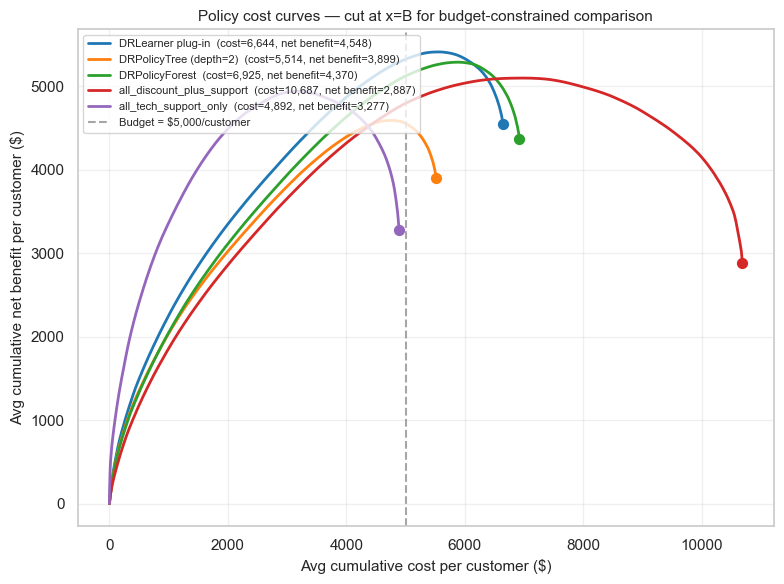

In [23]:
def policy_cost_curve(pi_eval, gamma_matrix, c_hat_matrix):
    """
    Generate cost curves using per-treatment estimated customer costs.
    c_hat_matrix[i, a] = Ê[C(a) | X_i]

    x = cumulative average treatment cost per customer (gross)
    y = cumulative average net profit per customer (costs already deducted from Y_net)

    Treated customers are sorted in descending order of net profit / estimated cost ratio.
    """
    pi = np.asarray(pi_eval).ravel().astype(int)
    n = len(pi)
    treated = pi > 0
    if treated.sum() == 0:
        return np.array([0.0]), np.array([0.0])

    benefit = gamma_matrix[np.arange(n), pi] - gamma_matrix[:, 0]
    cost    = c_hat_matrix[np.arange(n), pi].astype(float)

    b_t, c_t = benefit[treated], cost[treated]
    ratio = np.where(c_t > 0, b_t / c_t, b_t)
    order = np.argsort(-ratio)

    cum_cost    = np.r_[0, np.cumsum(c_t[order])]
    cum_benefit = np.r_[0, np.cumsum(b_t[order])]
    return cum_cost / n, cum_benefit / n


n_test = len(X_test)
policies_curve = [
    ('DRLearner plug-in',         pi_plugin),
    ('DRPolicyTree (depth=2)',     pi_tree),
    ('DRPolicyForest',            pi_forest),
    ('all_discount_plus_support', np.full(n_test, 3)),
    ('all_tech_support_only',     np.full(n_test, 1)),
]

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

for (name, pi_eval), color in zip(policies_curve, colors):
    cc, cg = policy_cost_curve(pi_eval, gamma_net, c_hat_test)
    ax.plot(cc, cg, lw=2, color=color,
            label=f'{name}  (cost={cc[-1]:,.0f}, net benefit={cg[-1]:,.0f})')
    ax.scatter([cc[-1]], [cg[-1]], s=50, color=color, zorder=5)

budget_example = 5_000
ax.axvline(budget_example, color='gray', lw=1.5, ls='--', alpha=0.7,
           label=f'Budget = ${budget_example:,}/customer')

ax.set_xlabel('Avg cumulative cost per customer ($)', fontsize=11)
ax.set_ylabel('Avg cumulative net benefit per customer ($)', fontsize=11)
ax.set_title('Policy cost curves — cut at x=B for budget-constrained comparison', fontsize=11)
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The most effective policy varies with the available budget. At low budgets of \$1,000\u2013\$3,000, `all_tech_support_only` is the most efficient. Its lower average cost means that even a small budget can reach many high benefit-to-cost customers quickly.

As the budget grows to \$4,000\u2013\$6,000, the learned policies (plug-in, forest) pull ahead. Customer-level targeting starts paying off, delivering higher net profit for the same spend.

Even when budgets are fully exhausted, the learned policies remain most efficient. Plug-in spends approximately \$6,600 to yield \$4,561 in net profit, and forest spends around \$6,900 for \$4,376. By contrast, `all_discount_plus_support` exhausts \$10,700 and still achieves only \$2,887 in net profit, making it the least efficient in terms of budget utilization.

## References

This notebook draws on Athey & Wager (2021) and the Stanford ML+CI Tutorial on Policy Learning.

- **Athey, S., & Wager, S. (2021)**. Policy Learning with Observational Data. *Econometrica*.
  [https://arxiv.org/abs/1702.02896](https://arxiv.org/abs/1702.02896)

- **Sun, L., Du, X., Wager, S., et al. (2021)**. Treatment Allocation under Uncertain Costs.
  [https://arxiv.org/abs/2103.11066](https://arxiv.org/abs/2103.11066)

- **Imai, K., & Li, M. L. (2019)**. Experimental Evaluation of Individualized Treatment Rules.
  [https://arxiv.org/pdf/1905.05389.pdf](https://arxiv.org/pdf/1905.05389.pdf)

- **Stanford ML+CI Tutorial — Policy Learning I (Binary Treatment)**.
  [https://bookdown.org/stanfordgsbsilab/ml-ci-tutorial/policy-learning-i---binary-treatment.html](https://bookdown.org/stanfordgsbsilab/ml-ci-tutorial/policy-learning-i---binary-treatment.html)

- **arXiv 2604.06123**.
  [https://arxiv.org/html/2604.06123v1](https://arxiv.org/html/2604.06123v1)